In [1]:
import pandas as pd
import numpy as np


from sklearn import model_selection, metrics, preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('S06-hw-dataset-01.csv')

In [3]:
# первые строки
print(df.head())

   id     num01     num02     num03     num04     num05     num06     num07  \
0   1 -0.946058 -0.070313  1.824445 -2.754422  0.808865 -0.111094 -0.268950   
1   2 -2.484027  0.739378  1.596908 -2.586479 -0.033225 -3.054412 -4.706908   
2   3  1.522629  7.159635 -0.564903 -4.493110  1.623610  5.450187 -0.974595   
3   4  0.463373 -1.073908  1.752813  0.362786  2.790872  4.082385  0.322283   
4   5  3.188390 -4.701692 -0.689918 -0.448995  0.373821 -3.275363 -1.760931   

      num08     num09  ...     num20     num21     num22     num23     num24  \
0 -3.078210  0.801275  ... -1.616515 -1.989464  1.407390 -0.218362  2.016052   
1 -9.795169  0.145911  ... -1.727040 -0.583997  1.136761  0.285978 -0.310879   
2 -5.189589  1.600591  ...  0.524408  2.022430  1.278358 -0.850547  0.847457   
3  3.390984 -0.033929  ...  2.399834 -1.431576 -0.746987  0.049639  2.414689   
4  0.923689  0.537345  ... -2.183407 -2.896590  2.440343 -1.097168  1.457323   

   cat_contract  cat_region  cat_payment  te

In [4]:
# основная информация
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [5]:
print(df.describe())

                id         num01         num02         num03         num04  \
count  12000.00000  12000.000000  12000.000000  12000.000000  12000.000000   
mean    6000.50000      0.013705     -0.005278     -0.002357      0.038404   
std     3464.24595      2.096534      3.544498      1.004417      2.087318   
min        1.00000     -8.155181    -14.605579     -4.374043     -7.753301   
25%     3000.75000     -1.423844     -2.303772     -0.685618     -1.374579   
50%     6000.50000     -0.047565      0.053348     -0.009186      0.038766   
75%     9000.25000      1.422676      2.335937      0.671441      1.484417   
max    12000.00000      8.610863     16.299709      3.651692      7.571965   

              num05         num06         num07         num08         num09  \
count  12000.000000  12000.000000  12000.000000  12000.000000  12000.000000   
mean      -0.006301     -0.865297     -0.702877     -0.290694     -0.008154   
std        1.007329      3.888966      1.989513      3.45598

In [6]:
df.shape

(12000, 30)

In [7]:
# проверка пропусков
print(df.isnull().sum())

id               0
num01            0
num02            0
num03            0
num04            0
num05            0
num06            0
num07            0
num08            0
num09            0
num10            0
num11            0
num12            0
num13            0
num14            0
num15            0
num16            0
num17            0
num18            0
num19            0
num20            0
num21            0
num22            0
num23            0
num24            0
cat_contract     0
cat_region       0
cat_payment      0
tenure_months    0
target           0
dtype: int64


пропусков нет

In [9]:
# типы столбцов
print(df.dtypes)

id                 int64
num01            float64
num02            float64
num03            float64
num04            float64
num05            float64
num06            float64
num07            float64
num08            float64
num09            float64
num10            float64
num11            float64
num12            float64
num13            float64
num14            float64
num15            float64
num16            float64
num17            float64
num18            float64
num19            float64
num20            float64
num21            float64
num22            float64
num23            float64
num24            float64
cat_contract       int64
cat_region         int64
cat_payment        int64
tenure_months      int64
target             int64
dtype: object


In [10]:
# распределение таргета
target_distribution = df['target'].value_counts(normalize=True)
print(target_distribution)
print("\nАбсолютные значения:\n", df['target'].value_counts())

target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

Абсолютные значения:
 target
0    8119
1    3881
Name: count, dtype: int64


In [11]:
# признаки (исключаем 'id' и 'target')
X = df.drop(columns=['id', 'target'])

# таргет y
y = df['target']

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=17,
    stratify=y
)

# размеры выборок
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

# распределение классов
print("Распределение классов в исходных данных")
print(y.value_counts(normalize=True))

print("...в тренировочной выборке")
print(y_train.value_counts(normalize=True))

print("...в тестовой выборке")
print(y_test.value_counts(normalize=True))

X_train: (9600, 28)
X_test: (2400, 28)
y_train: (9600,)
y_test: (2400,)
Распределение классов в исходных данных
target
0    0.676583
1    0.323417
Name: proportion, dtype: float64
...в тренировочной выборке
target
0    0.676562
1    0.323437
Name: proportion, dtype: float64
...в тестовой выборке
target
0    0.676667
1    0.323333
Name: proportion, dtype: float64


Фиксированный seed (random_state=17) важен для воспроизводимости результатов: при каждом запуске кода разделение на выборки будет происходить одинаково. Это нужно для сравнения разных моделей на одинаковых данных, публикации результатов, поиска и исправления ошибок

Стратификация (stratify=y) нужна для сохранения распределения классов: в train и test выборках пропорции классов практически такие же как в исходных классах. Это важно при несбалансированных данных (как например в этой ситуациии 32:68). Без стратификации в выборке может оказаться чересчур много/мало объектов одного из классов, из-за чего модель обучится неправильно (например может полностью проигнорировать редкий класс)

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [15]:
# DummyClassifier
# стратегия stratified

dummy_strat = DummyClassifier(strategy='stratified', random_state=17)
dummy_strat.fit(X_train, y_train)

y_pred_strat = dummy_strat.predict(X_test)

print(f"Accuracy на тесте: {metrics.accuracy_score(y_test, y_pred_strat):.4f}")

print(f"\nМатрица ошибок:")
print(metrics.confusion_matrix(y_test, y_pred_strat))

Accuracy на тесте: 0.5650

Матрица ошибок:
[[1097  527]
 [ 517  259]]


In [16]:
# pipeline: StandardScaler + LogisticRegression

logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        random_state=17,
        max_iter=1000,
        class_weight='balanced'
    ))
])


logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)


print(f"\nAccuracy на тесте: {metrics.accuracy_score(y_test, y_pred_logreg):.4f}")

print(f"\nМатрица ошибок:")
print(metrics.confusion_matrix(y_test, y_pred_logreg))


Accuracy на тесте: 0.8250

Матрица ошибок:
[[1359  265]
 [ 155  621]]


In [17]:
# метрики
print("DummyClassifier (most_frequent)")
y_pred = dummy_strat.predict(X_test)
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"F1: {metrics.f1_score(y_test, y_pred, zero_division=0):.4f}")
print("ROC-AUC: N/A (нет вероятностей)")
print()


print("LogisticRegression")
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]
print(f"Accuracy: {metrics.accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"F1: {metrics.f1_score(y_test, y_pred_logreg):.4f}")
print(f"ROC-AUC: {metrics.roc_auc_score(y_test, y_proba_logreg):.4f}")

DummyClassifier (most_frequent)
Accuracy: 0.5650
F1: 0.3316
ROC-AUC: N/A (нет вероятностей)

LogisticRegression
Accuracy: 0.8250
F1: 0.7473
ROC-AUC: 0.8861


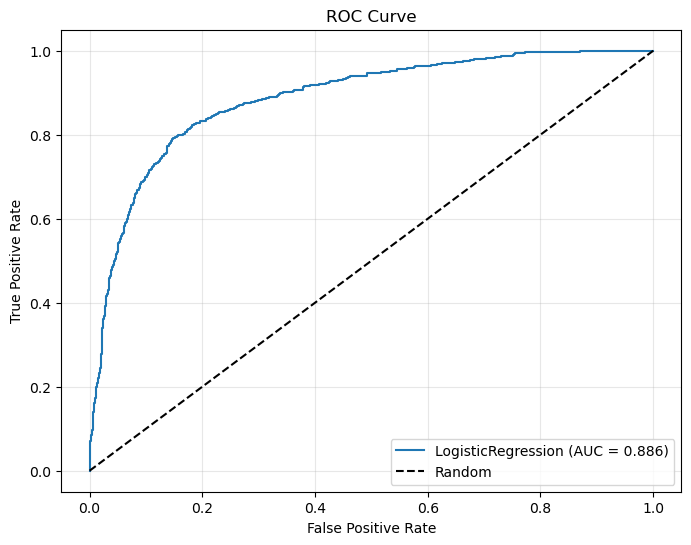

In [18]:
# ROC-кривая
fpr, tpr, _ = metrics.roc_curve(y_test, y_proba_logreg)
roc_auc = metrics.roc_auc_score(y_test, y_proba_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LogisticRegression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

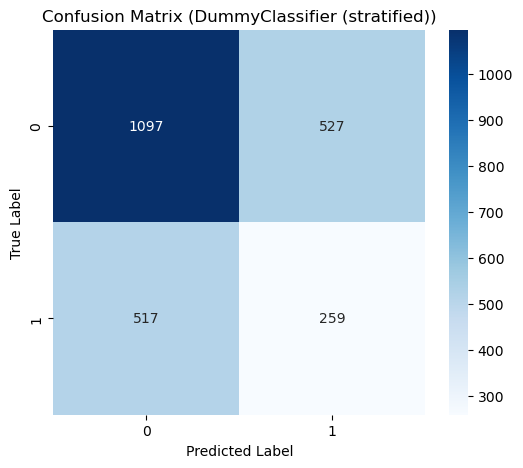

In [19]:
cm_strat = metrics.confusion_matrix(y_test, dummy_strat.predict(X_test))
plt.figure(figsize=(6, 5))
sns.heatmap(cm_strat, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (DummyClassifier (stratified))')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

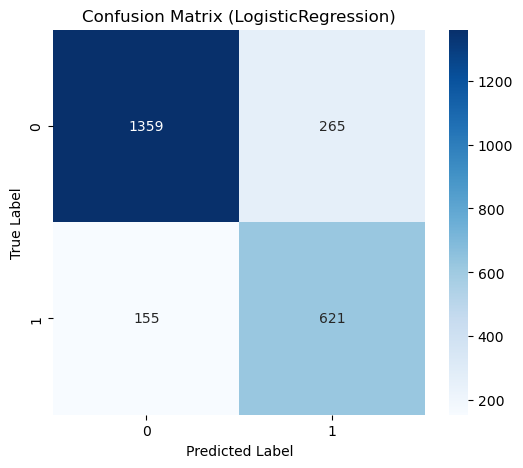

In [20]:
cm = metrics.confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (LogisticRegression)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# DecisionTreeClassifier 

# параметры для GridSearch
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'criterion': ['gini', 'entropy']
}


tree_clf = DecisionTreeClassifier(random_state=17)
tree_grid = GridSearchCV(
    tree_clf, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [22]:
tree_grid.fit(X_train, y_train)

Fitting 5 folds for each of 70 candidates, totalling 350 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=17), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 5, 10, 20]},
             scoring='roc_auc', verbose=1)

In [23]:
print("Результаты GridSearchCV")
print(f"Лучшие параметры: {tree_grid.best_params_}")
print(f"Лучший score (ROC-AUC) на CV: {tree_grid.best_score_:.4f}")
print()

Результаты GridSearchCV
Лучшие параметры: {'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 20}
Лучший score (ROC-AUC) на CV: 0.9111



In [24]:
# оценка на тестовой выборке
best_tree = tree_grid.best_estimator_
y_pred_tree = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]

In [25]:
# метрики

print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_tree):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_tree):.4f}")

Accuracy: 0.8617
F1-Score: 0.7751
ROC-AUC: 0.9240


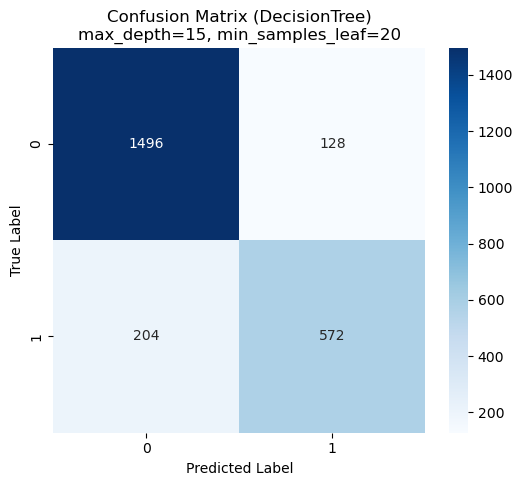

In [26]:
# матрица ошибок

cm_tree = metrics.confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (DecisionTree)\nmax_depth={best_tree.max_depth}, min_samples_leaf={best_tree.min_samples_leaf}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

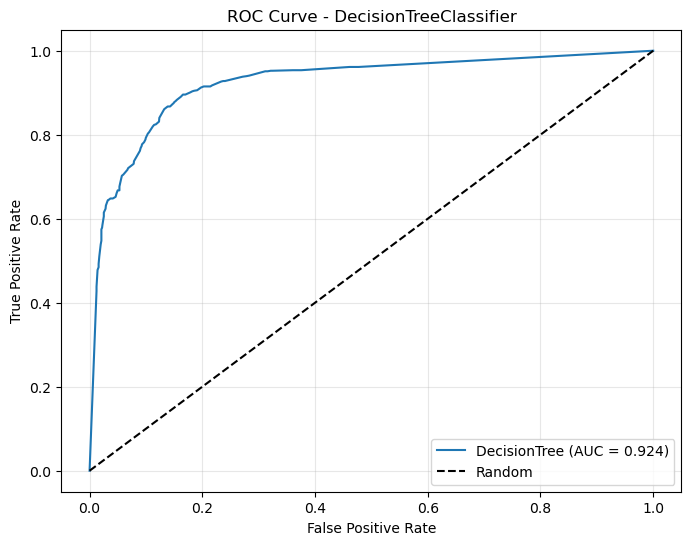

In [27]:
# ROC-кривая

fpr_tree, tpr_tree, _ = metrics.roc_curve(y_test, y_proba_tree)
roc_auc_tree = roc_auc_score(y_test, y_proba_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr_tree, tpr_tree, label=f'DecisionTree (AUC = {roc_auc_tree:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DecisionTreeClassifier')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [28]:
# RandomForestClassifier

# параметры для GridSearch
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5],
    'bootstrap': [True]
}


rf_clf = RandomForestClassifier(random_state=17, n_jobs=-1)
rf_grid = GridSearchCV(
    rf_clf,
    param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [29]:
rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=17),
             n_jobs=-1,
             param_grid={'bootstrap': [True], 'max_depth': [5, 10, 15, None],
                         'max_features': ['sqrt', 0.5],
                         'min_samples_leaf': [1, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [30]:
print("Результаты GridSearchCV")
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший ROC-AUC на CV: {rf_grid.best_score_:.4f}")

Результаты GridSearchCV
Лучшие параметры: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 200}
Лучший ROC-AUC на CV: 0.9694


In [31]:
best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

In [32]:
# метрики
print("Метрики RandomForest на тестовой выборке:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

Метрики RandomForest на тестовой выборке:
Accuracy: 0.9300
F1-Score: 0.8849
ROC-AUC: 0.9680


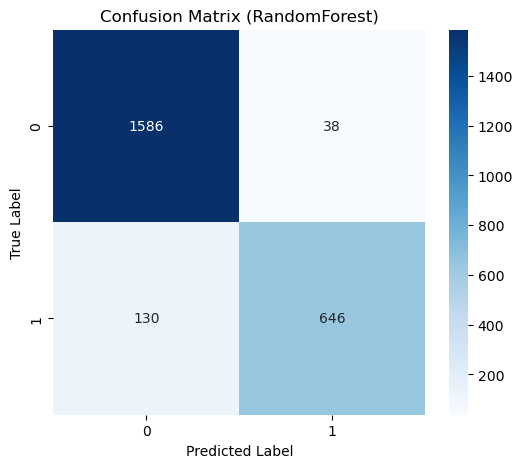

In [33]:
# матрица ошибок

cm_rf = metrics.confusion_matrix(y_test, best_rf.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (RandomForest)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

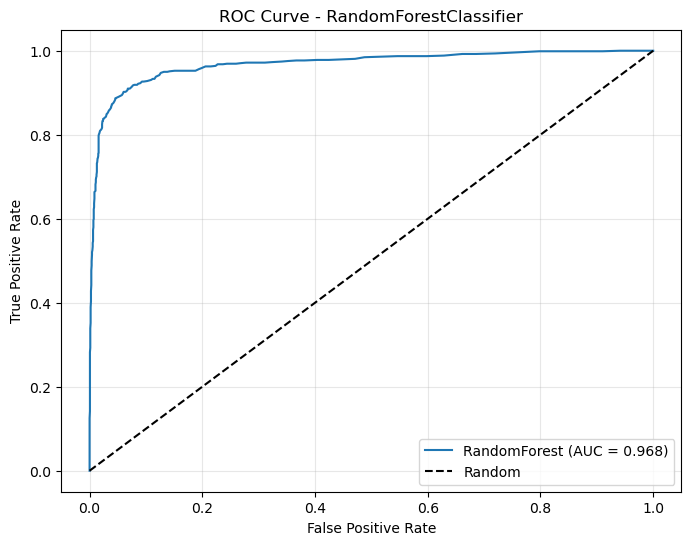

In [34]:
# ROC-кривая
fpr_rf, tpr_rf, _ = metrics.roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])
roc_auc_rf = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'RandomForest (AUC = {roc_auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - RandomForestClassifier')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

# GradientBoostingClassifier

# параметры для GridSearch
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_leaf': [1, 5],
    'subsample': [0.8, 1.0] # Stochastic Gradient Boosting
}

gb_clf = GradientBoostingClassifier(random_state=17)
gb_grid = GridSearchCV(
    gb_clf,
    param_grid_gb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [36]:
gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=17),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'min_samples_leaf': [1, 5], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='roc_auc', verbose=1)

In [37]:
print("Результаты GridSearchCV для GradientBoosting")
print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший ROC-AUC на CV: {gb_grid.best_score_:.4f}")

Результаты GridSearchCV для GradientBoosting
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 0.8}
Лучший ROC-AUC на CV: 0.9713


In [38]:
best_gb = gb_grid.best_estimator_
y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)[:, 1]

In [39]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_gb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

Accuracy: 0.9350
F1-Score: 0.8956
ROC-AUC: 0.9736


In [116]:
from pathlib import Path
import os

figures_dir = Path("artifacts/figures")
figures_dir.mkdir(exist_ok=True)

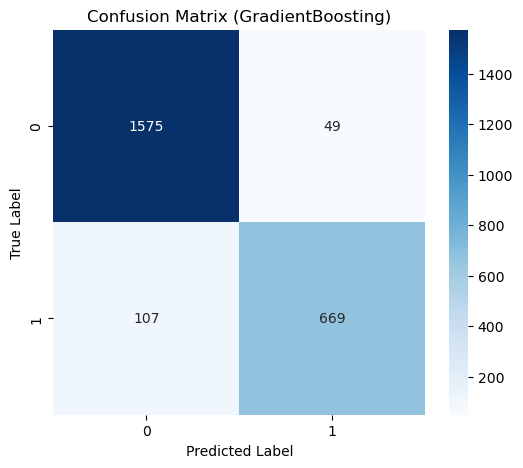

In [120]:
# матрица ошибок
cm_gb = metrics.confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (GradientBoosting)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

cm_path = figures_dir / "confusion_matrix_gradientboosting.png"
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()

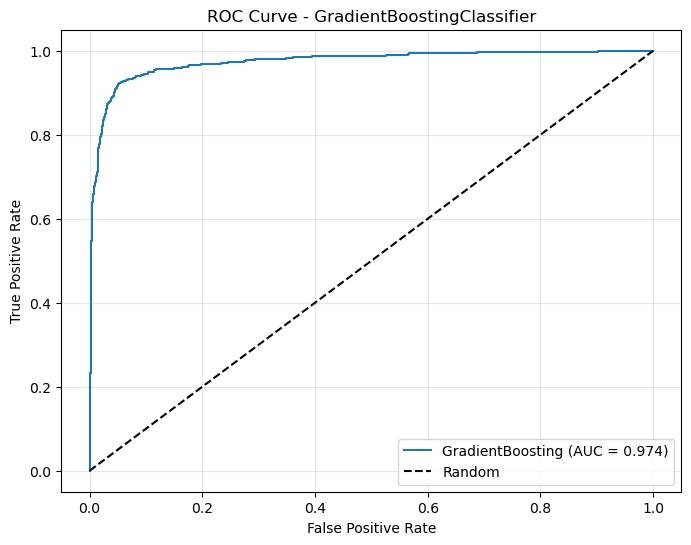

In [124]:
# ROC-кривая
fpr_gb, tpr_gb, _ = metrics.roc_curve(y_test, y_proba_gb)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, label=f'GradientBoosting (AUC = {roc_auc_gb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - GradientBoostingClassifier')
plt.legend()
plt.grid(alpha=0.3)

roc_path = figures_dir / "roc_curve_gradientboosting.png"
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.show()


In [42]:
# Собираем метрики всех моделей
models_data = {
    'LogisticRegression': {
        'model': logreg_pipeline,
        'y_proba': logreg_pipeline.predict_proba(X_test)[:, 1],
        'roc_auc': roc_auc_score(y_test, logreg_pipeline.predict_proba(X_test)[:, 1])
    },
    'DecisionTree': {
        'model': best_tree,
        'y_proba': best_tree.predict_proba(X_test)[:, 1],
        'roc_auc': roc_auc_tree
    },
    'RandomForest': {
        'model': best_rf,
        'y_proba': best_rf.predict_proba(X_test)[:, 1],
        'roc_auc': roc_auc_rf
    },
    'GradientBoosting': {
        'model': best_gb,
        'y_proba': y_proba_gb,
        'roc_auc': roc_auc_gb
    }
}

In [43]:
comparison = []
for name, data in models_data.items():
    comparison.append({
        'Model': name,
        'ROC-AUC': data['roc_auc'],
        'Accuracy': accuracy_score(y_test, data['model'].predict(X_test)),
        'F1-Score': f1_score(y_test, data['model'].predict(X_test))
    })

In [44]:
comparison_df = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
print("\nСравнение моделей по ROC-AUC:")
print(comparison_df.to_string(index=False))


Сравнение моделей по ROC-AUC:
             Model  ROC-AUC  Accuracy  F1-Score
  GradientBoosting 0.973589  0.935000  0.895582
      RandomForest 0.968037  0.930000  0.884932
      DecisionTree 0.924004  0.861667  0.775068
LogisticRegression 0.886073  0.825000  0.747292


In [45]:
# Выбираем лучшую модель
best_model_name = comparison_df.iloc[0]['Model']
best_model = models_data[best_model_name]['model']
print(f"\nЛучшая модель: {best_model_name} (ROC-AUC = {comparison_df.iloc[0]['ROC-AUC']:.4f})")


Лучшая модель: GradientBoosting (ROC-AUC = 0.9736)


In [46]:
from sklearn.inspection import permutation_importance

# permutation importance для лучшей модели
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=17,
    scoring='roc_auc',
    n_jobs=-1
)

# DataFrame с результатами
perm_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("Топ-15 признаков по permutation importance:")
top_features = perm_importance_df.head(15)
print(top_features.to_string(index=False))

Топ-15 признаков по permutation importance:
feature  importance_mean  importance_std
  num18         0.074486        0.003418
  num19         0.063032        0.004155
  num07         0.029144        0.001003
  num04         0.015123        0.001154
  num24         0.012636        0.001657
  num20         0.011384        0.001358
  num14         0.009103        0.000970
  num01         0.008444        0.000982
  num22         0.007765        0.001441
  num16         0.005935        0.000657
  num08         0.004979        0.001090
  num17         0.003562        0.000619
  num06         0.002767        0.000492
  num13         0.002557        0.000444
  num21         0.002071        0.001078


Интерпретация результатов

num18 и num19 наибольшее значимые признаки с большим отрывом от остальным признаков. Следующие по важности - признаки num07 и num04. Остальные признаки имеют влияние на модель, но оно минимально и их исключение не сильно ухудшит качество модели

Низкий std (например, у num18 — 0.0034) указывает на устойчивость оценки важности

Категориальные признаки (cat_contract, cat_region, cat_payment) могут иметь маленькую значимость в этих данных, либо требовать иного кодирования

In [48]:
import json
import os
from pathlib import Path
import pandas as pd


artifacts_dir = Path("artifacts/")
artifacts_dir.mkdir(parents=True, exist_ok=True)


models_info = {
    'Dummy_stratified': {
        'accuracy': float(accuracy_score(y_test, dummy_strat.predict(X_test))),
        'f1': float(f1_score(y_test, dummy_strat.predict(X_test), zero_division=0)),
        'roc_auc': 'N/A',
        'params': str(dummy_strat.get_params())
    },
    'LogisticRegression': {
        'accuracy': float(accuracy_score(y_test, logreg_pipeline.predict(X_test))),
        'f1': float(f1_score(y_test, logreg_pipeline.predict(X_test))),
        'roc_auc': float(roc_auc_score(y_test, logreg_pipeline.predict_proba(X_test)[:, 1])),
        'params': str(logreg_pipeline.get_params())
    },
    'DecisionTree': {
        'accuracy': float(accuracy_score(y_test, best_tree.predict(X_test))),
        'f1': float(f1_score(y_test, best_tree.predict(X_test))),
        'roc_auc': float(roc_auc_tree),
        'params': str(best_tree.get_params())
    },
    'RandomForest': {
        'accuracy': float(accuracy_score(y_test, best_rf.predict(X_test))),
        'f1': float(f1_score(y_test, best_rf.predict(X_test))),
        'roc_auc': float(roc_auc_rf),
        'params': str(best_rf.get_params())
    },
    'GradientBoosting': {
        'accuracy': float(accuracy_score(y_test, best_gb.predict(X_test))),
        'f1': float(f1_score(y_test, best_gb.predict(X_test))),
        'roc_auc': float(roc_auc_gb),
        'params': str(best_gb.get_params())
    }
}

In [49]:
# сохраняем в JSON
json_path = artifacts_dir / "metrics_test.json"
with open(json_path, 'w') as f:
    json.dump(models_info, f, indent=2)

print("Метрики всех моделей сохранены в JSON")



Метрики всех моделей сохранены в JSON


In [104]:
search_summaries = {}

search_summaries['DecisionTree'] = {
    'best_params': tree_grid.best_params_,
    'best_cv_score': float(tree_grid.best_score_),
    'cv_folds': 5,
    'param_grid': param_grid,
    'n_combinations': len(param_grid['max_depth']) * len(param_grid['min_samples_leaf']) * len(param_grid['criterion']),
    'total_fits': tree_grid.n_splits_ * len(tree_grid.cv_results_['params'])
}

search_summaries['RandomForest'] = {
    'best_params': rf_grid.best_params_,
    'best_cv_score': float(rf_grid.best_score_),
    'cv_folds': 5,
    'param_grid': param_grid_rf,
    'n_combinations': len(param_grid_rf['n_estimators']) * len(param_grid_rf['max_depth']) * len(param_grid_rf['min_samples_leaf']) * len(param_grid_rf['max_features']) * len(param_grid_rf['bootstrap']),
    'total_fits': rf_grid.n_splits_ * len(rf_grid.cv_results_['params'])
}

search_summaries['GradientBoosting'] = {
    'best_params': gb_grid.best_params_,
    'best_cv_score': float(gb_grid.best_score_),
    'cv_folds': 5,
    'param_grid': param_grid_gb,
    'n_combinations': len(param_grid_gb['n_estimators']) * len(param_grid_gb['learning_rate']) * len(param_grid_gb['max_depth']) * len(param_grid_gb['min_samples_leaf']) * len(param_grid_gb['subsample']),
    'total_fits': gb_grid.n_splits_ * len(gb_grid.cv_results_['params'])
}

In [110]:
# Сохраняем в JSON (ТОЛЬКО модели с подбором гиперпараметров)
search_json_path = artifacts_dir / "search_summaries.json"
with open(search_json_path, 'w') as f:
    json.dump(search_summaries, f, indent=2, default=str)

print("search_summaries.json сохранен")


search_summaries.json сохранен


In [112]:
import joblib

best_model_path = artifacts_dir / "best_model.joblib"
joblib.dump(gb_grid.best_estimator_, best_model_path)

print("Лучшая модель сохранена")

Лучшая модель сохранена


In [114]:
best_model_meta = {
    "best_model": "GradientBoosting",
    "selection_criteria": "highest_roc_auc_on_test",
    "test_metrics": {
        "accuracy": 0.935,
        "f1": 0.8955823293172691,
        "roc_auc": 0.9735888223046062
    },
    "best_params": {
        "learning_rate": 0.1,
        "max_depth": 5,
        "min_samples_leaf": 5,
        "n_estimators": 200,
        "subsample": 0.8
    },
    "model_comparison": {
        "Dummy_stratified": {
            "accuracy": 0.565,
            "f1": 0.33162612035851474,
            "roc_auc": "N/A"
        },
        "LogisticRegression": {
            "accuracy": 0.825,
            "f1": 0.7472924187725631,
            "roc_auc": 0.8860734282159363
        },
        "DecisionTree": {
            "accuracy": 0.8616666666666667,
            "f1": 0.7750677506775068,
            "roc_auc": 0.9240039865928598
        },
        "RandomForest": {
            "accuracy": 0.93,
            "f1": 0.8849315068493151,
            "roc_auc": 0.9680370315118582
        },
        "GradientBoosting": {
            "accuracy": 0.935,
            "f1": 0.8955823293172691,
            "roc_auc": 0.9735888223046062
        }
    },
    "notes": "GradientBoosting показал наилучший ROC-AUC на тестовой выборке"
}


meta_json_path = artifacts_dir / "best_model_meta.json"
with open(meta_json_path, 'w') as f:
    json.dump(best_model_meta, f, indent=2)

print("best_model_meta.json сохранен")


best_model_meta.json сохранен
